<a href="https://colab.research.google.com/github/MeghanaGS26/customer-churn-prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()
print(df.isnull().sum().sum(), "missing values (before cleaning)")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# TotalCharges is stored as text because some rows are blank spaces
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].isnull().sum(), "blank TotalCharges rows")

# These are new customers with tenure = 0, so fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# customerID is useless for modeling
df = df.drop("customerID", axis=1)

# Target as 0/1
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

11 blank TotalCharges rows


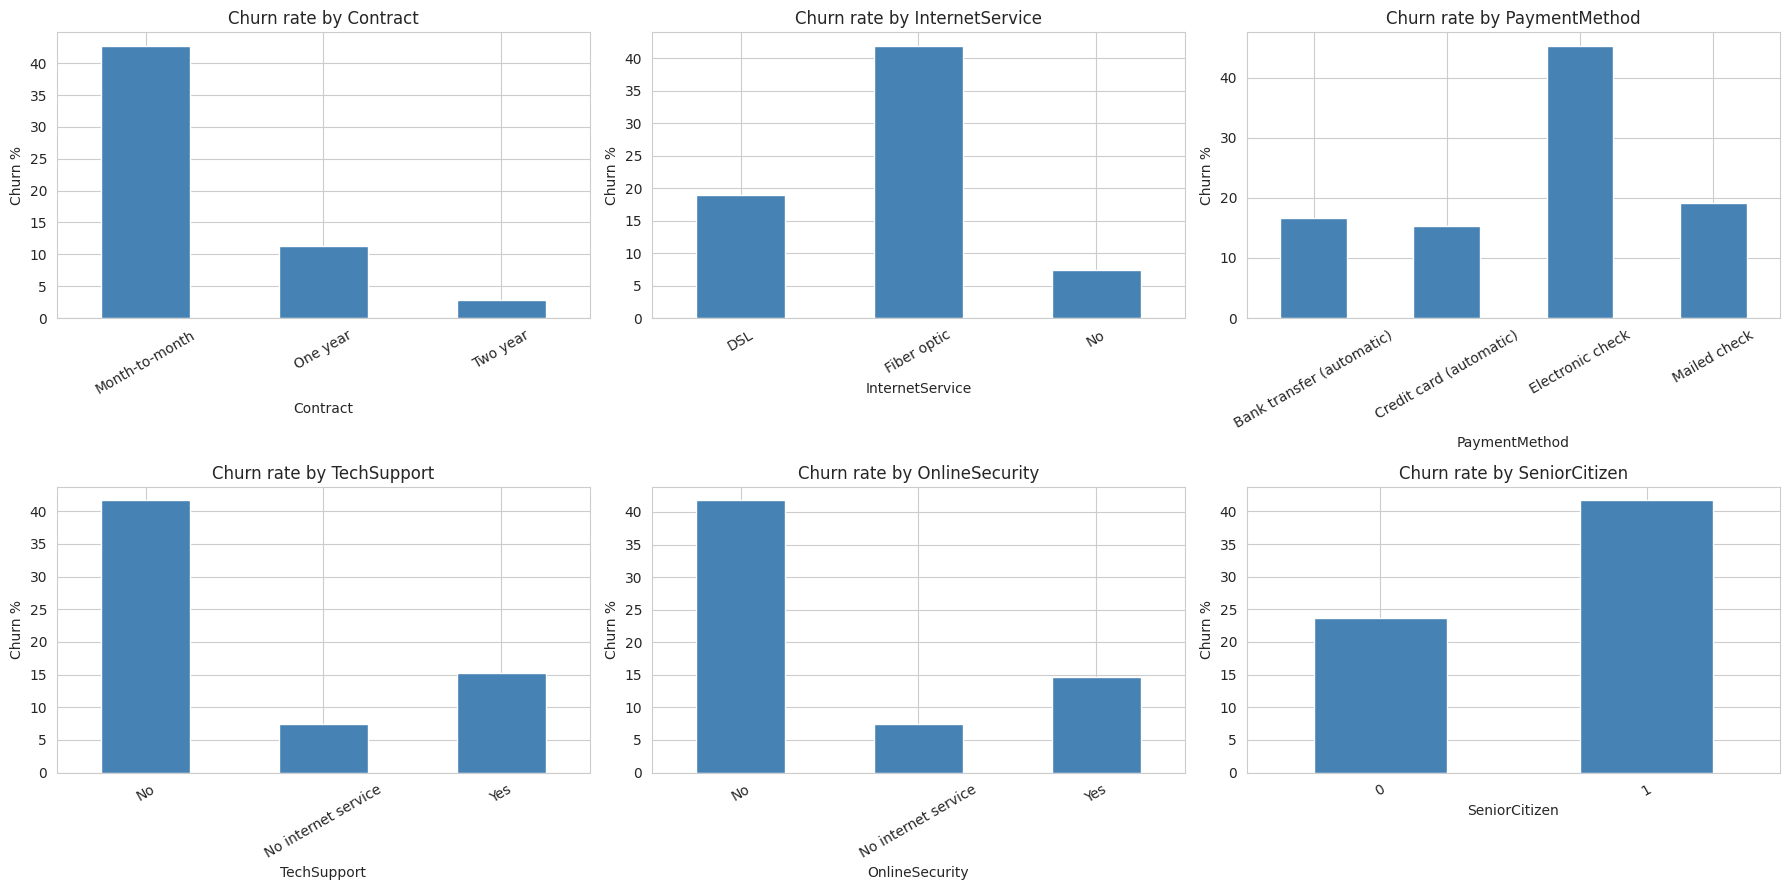

In [5]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity", "SeniorCitizen"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    rate = df.groupby(col)["Churn"].mean() * 100
    rate.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn %")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

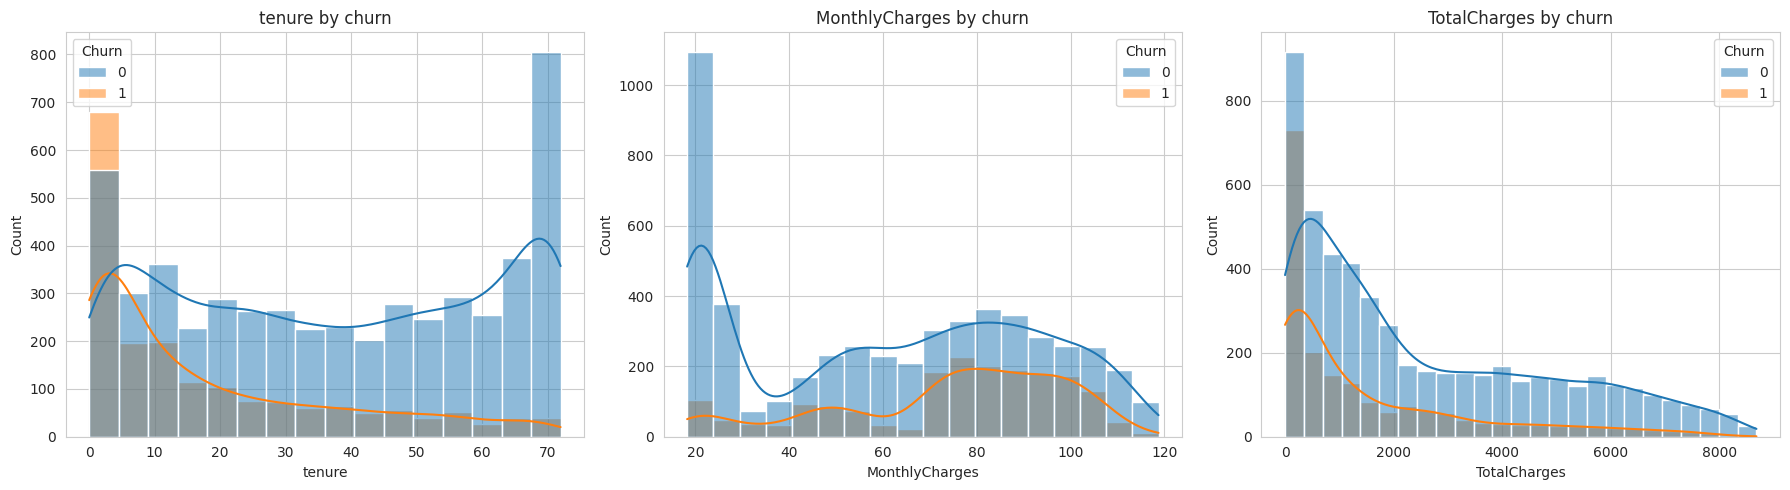

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.show()

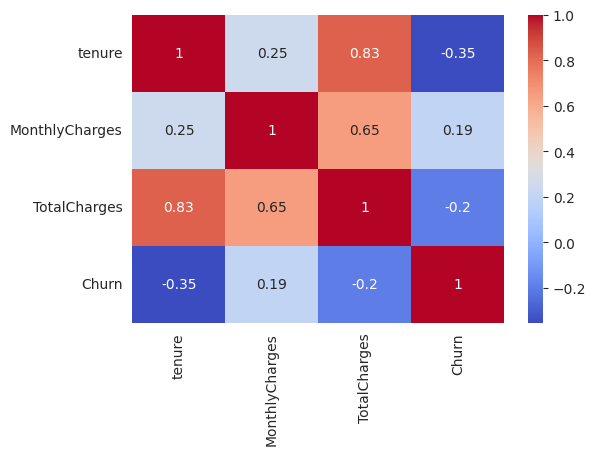

In [7]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr(), annot=True, cmap="coolwarm")
plt.show()

In [8]:
# Convert text columns to numbers (one-hot encoding)
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]
print(X.shape)

(7043, 30)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(y_train.mean(), y_test.mean())  # churn rate should be similar in both

0.2653532126375577 0.2654364797728886


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier

# Ratio of non-churn to churn, used to handle imbalance in XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        scale_pos_weight=ratio, eval_metric="logloss", random_state=42
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
print("Training done")

Training done


In [11]:
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score)

results = []
for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.740,0.507,0.786,0.616,0.841
Random Forest,0.790,0.634,0.495,0.556,0.826
XGBoost,0.752,0.521,0.786,0.627,0.839


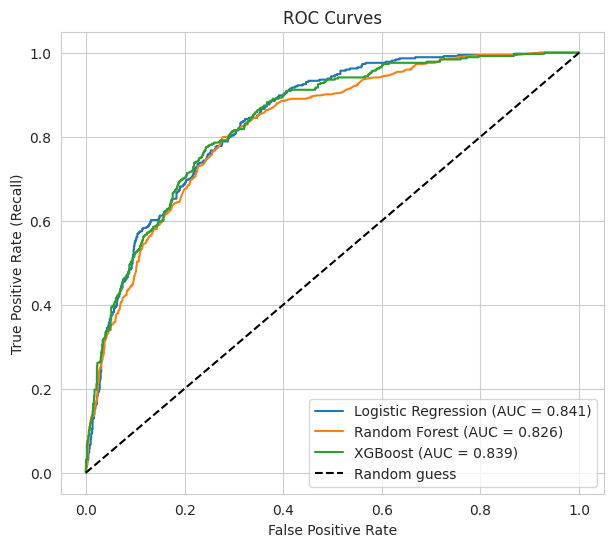

In [12]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves")
plt.legend()
plt.show()

Best model: Logistic Regression


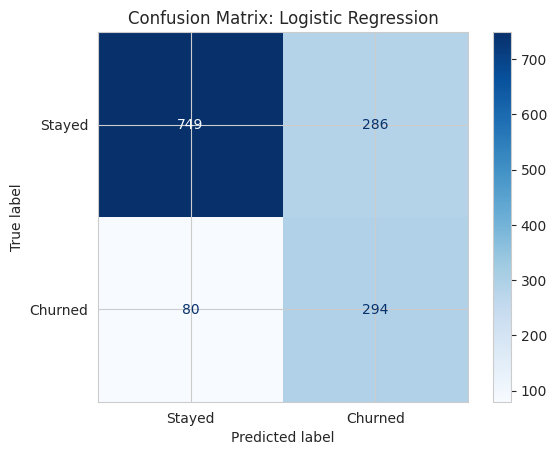

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

best_name = results_df["ROC-AUC"].idxmax()
print("Best model:", best_name)

ConfusionMatrixDisplay.from_estimator(
    models[best_name], X_test, y_test,
    display_labels=["Stayed", "Churned"], cmap="Blues"
)
plt.title(f"Confusion Matrix: {best_name}")
plt.show()

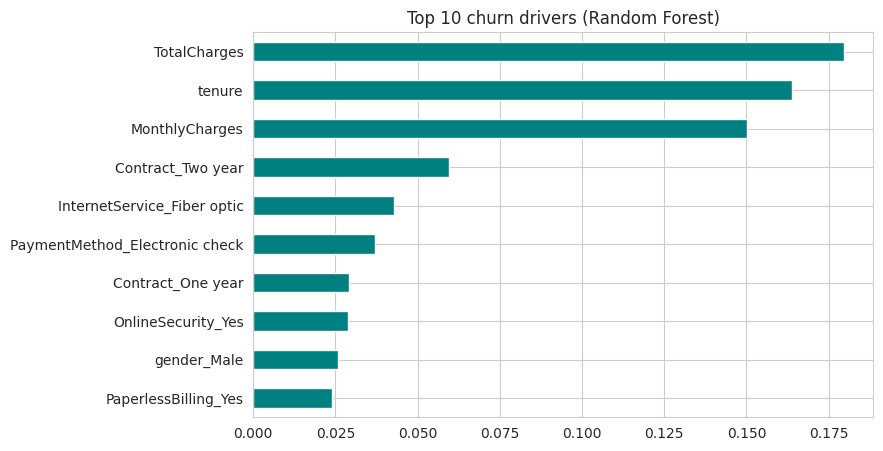

In [14]:
rf = models["Random Forest"]
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 churn drivers (Random Forest)")
plt.show()

## Key Findings
- Customers on **month-to-month contracts** churn far more than those on 1- or 2-year contracts.
- **Short-tenure customers** (first year) are the most likely to leave.
- **Fiber optic** and **electronic check** customers show higher churn.
- Customers without **tech support** or **online security** churn more.

## Model Results
- Best model by ROC-AUC: Logistic Regression (AUC = 0.84)
- Recall for churners: 0.786, meaning the model catches about 79% of customers who actually leave.

## Business Recommendations
1. Offer discounts or incentives to move month-to-month customers to annual plans.
2. Run onboarding and check-in programs for customers in their first 12 months.
3. Bundle tech support and online security into plans.
4. Target customers the model flags as high risk with retention offers.